# House Price - Benchmark Machine Learning và MLP NumPy

Notebook này huấn luyện và đối chuẩn 4 mô hình regression trên dataset `realtor-data.zip.csv`:

- **Ridge Regression**
- **Decision Tree Regressor**
- **Random Forest Regressor**
- **MLP đa tầng thuần NumPy**: `input -> 128 -> 64 -> 32 -> 1`

Target là `price`, nên đây là bài toán **hồi quy**. Dataset có hơn 2.2 triệu dòng và giá nhà lệch mạnh, vì vậy notebook dự đoán `log1p(price)` rồi chuyển ngược về đơn vị USD để đánh giá bằng **MAE, RMSE, MedianAE, MAPE, RMSLE, R2**, kèm thời gian train/predict và phân tích residual.


## 1. Kiểm tra thư viện

Notebook không tự động cài package. Nếu cell này báo thiếu thư viện, hãy cài trong môi trường Python/Jupyter đang dùng rồi chạy lại notebook.


In [20]:
import importlib.util

required_modules = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
}

missing = [pip_name for module_name, pip_name in required_modules.items()
           if importlib.util.find_spec(module_name) is None]

if missing:
    raise ModuleNotFoundError(
        "Notebook cần các package sau: " + ", ".join(missing) +
        ". Cài gợi ý: pip install numpy pandas scikit-learn matplotlib"
    )

import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 2. Load Data

Cell này tìm dataset theo đường dẫn tương đối `../data/realtor-data.zip.csv` khi chạy notebook từ thư mục `notebook`. Một vài đường dẫn dự phòng được thêm để notebook vẫn chạy được nếu kernel đang đứng ở thư mục gốc project.


In [21]:
candidate_paths = [
    Path("../data/realtor-data.zip.csv"),
    Path("data/realtor-data.zip.csv"),
    Path("src/Assigment 03/house_price/data/realtor-data.zip.csv"),
]

DATA_PATH = None
for candidate in candidate_paths:
    if candidate.exists():
        DATA_PATH = candidate.resolve()
        break

if DATA_PATH is None:
    searched = "; ".join(str(path) for path in candidate_paths)
    raise FileNotFoundError("Không tìm thấy dataset. Các đường dẫn đã thử: " + searched)

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Dataset path: {DATA_PATH}")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
display(df_raw.head())


Dataset path: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/house_price/data/realtor-data.zip.csv
Shape: 2,226,382 rows x 12 columns


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [22]:
# ============================================================
# FIGURE OUTPUT
# ============================================================

FIGURE_DIR = DATA_PATH.parent.parent / "report" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


def save_current_figure(filename):
    output_path = FIGURE_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure: {output_path}")
    return output_path


## 3. Kiểm tra dữ liệu ban đầu

Phần này kiểm tra kiểu dữ liệu, missing values, duplicate rows và phân phối target `price`.


In [23]:
print("Data types:")
display(df_raw.dtypes.to_frame("dtype"))

audit = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_percent": df_raw.isna().mean() * 100,
    "unique_values": df_raw.nunique(dropna=False),
})
print(f"Duplicate rows: {df_raw.duplicated().sum():,}")
display(audit)

price_numeric = pd.to_numeric(df_raw["price"], errors="coerce")
valid_price = price_numeric[price_numeric > 0]
print(f"Valid positive prices: {valid_price.notna().sum():,}")
display(valid_price.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("price"))

display(df_raw.describe(include="all").T)


Data types:


,dtype
brokered_by,float64
status,str
price,float64
bed,float64
bath,float64
acre_lot,float64
street,float64
city,str
state,str
zip_code,float64


Duplicate rows: 0


,missing_count,missing_percent,unique_values
brokered_by,4533,0.2036,110144
status,0,0.0000,3
price,1541,0.0692,102138
bed,481317,21.6188,100
bath,511771,22.9867,87
acre_lot,325589,14.6241,16058
street,10866,0.4881,2001359
city,1407,0.0632,20099
state,8,0.0004,56
zip_code,299,0.0134,30335


Valid positive prices: 2,224,561


,price
count,2.2246e+06
mean,5.2426e+05
std,2.1390e+06
min,1.0000e+00
1%,1.0000e+04
5%,3.0000e+04
25%,1.6500e+05
50%,3.2500e+05
75%,5.5000e+05
95%,1.4950e+06


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brokered_by,2221849.0,NaN,NaN,NaN,52939.8933,30642.7529,0.0,23861.0,52884.0,79183.0,110142.0
status,2226382,3,for_sale,1389306,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,2224841.0,NaN,NaN,NaN,524195.5193,2138893.2211,0.0,165000.0,325000.0,550000.0,2147483600.0
bed,1745065.0,NaN,NaN,NaN,3.2758,1.5673,1.0,3.0,3.0,4.0,473.0
bath,1714611.0,NaN,NaN,NaN,2.4964,1.6526,1.0,2.0,2.0,3.0,830.0
acre_lot,1900793.0,NaN,NaN,NaN,15.223,762.8238,0.0,0.15,0.26,0.98,100000.0
street,2215516.0,NaN,NaN,NaN,1012324.9207,583763.4783,0.0,506312.75,1012765.5,1521173.25,2001357.0
city,2224975,20098,Houston,23862,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,2226374,55,Florida,249432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,2226083.0,NaN,NaN,NaN,52186.6763,28954.0845,0.0,29617.0,48382.0,78070.0,99999.0


## 4. EDA ngắn

Các biểu đồ dưới đây giúp nhìn nhanh độ lệch của giá nhà, missing values và các nhóm `status`/`state` phổ biến.


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/house_price/report/figures/house_price_eda_overview.png


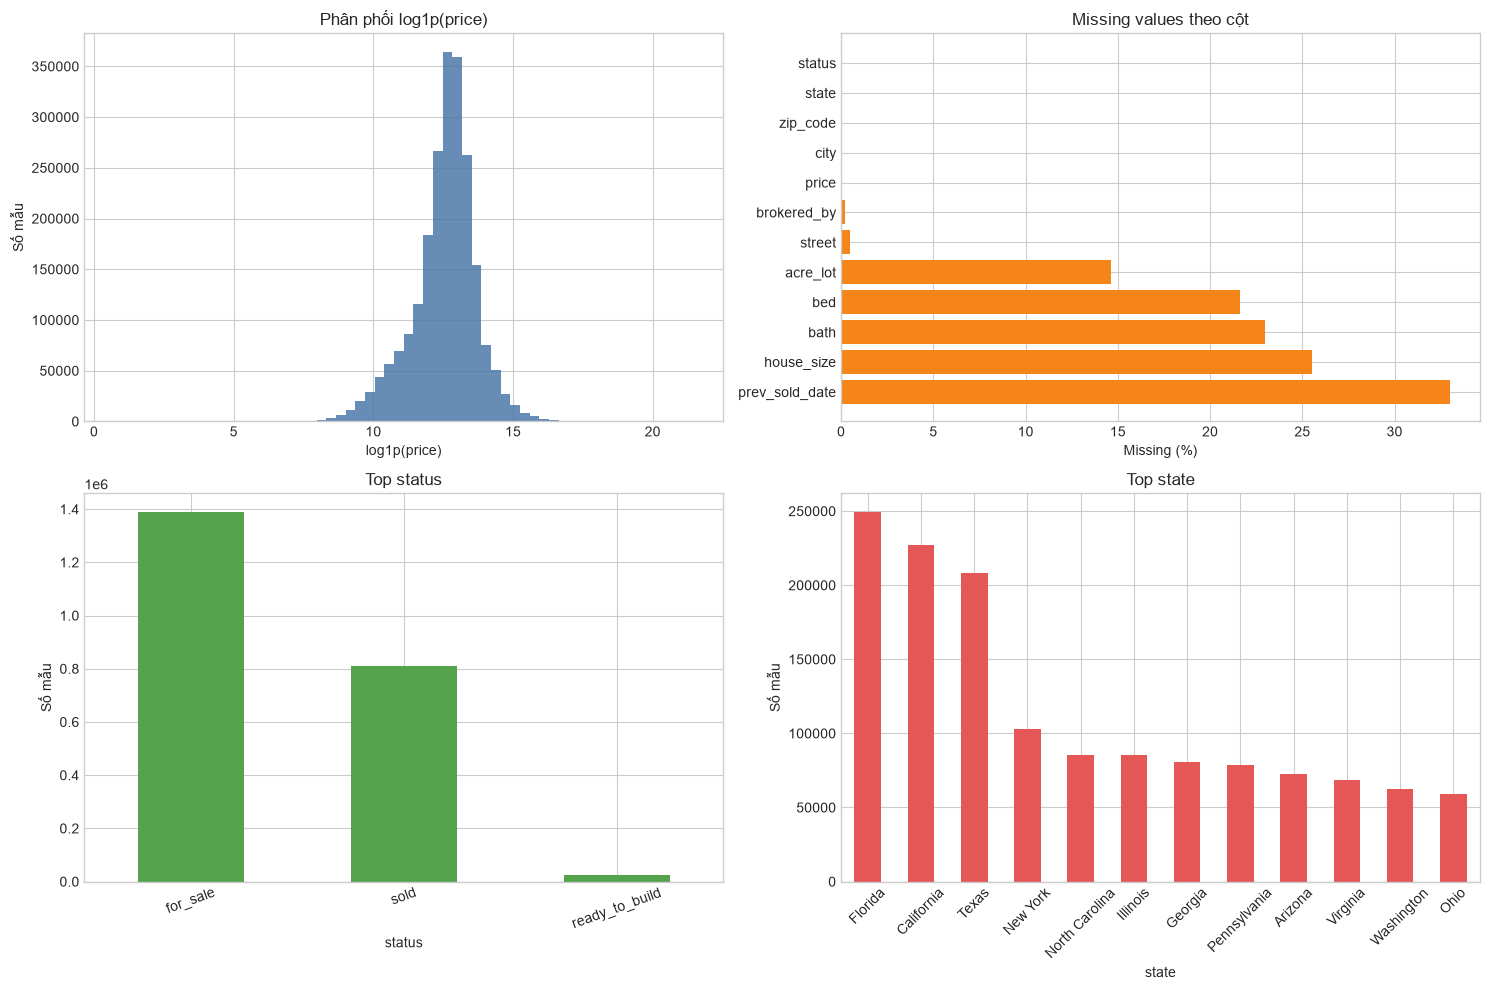

In [24]:
price_numeric = pd.to_numeric(df_raw["price"], errors="coerce")
valid_price = price_numeric[price_numeric > 0]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

axes[0].hist(np.log1p(valid_price), bins=60, color="#4C78A8", alpha=0.85)
axes[0].set_title("Phân phối log1p(price)")
axes[0].set_xlabel("log1p(price)")
axes[0].set_ylabel("Số mẫu")

missing_percent = df_raw.isna().mean().sort_values(ascending=False) * 100
axes[1].barh(missing_percent.index, missing_percent.values, color="#F58518")
axes[1].set_title("Missing values theo cột")
axes[1].set_xlabel("Missing (%)")

df_raw["status"].value_counts().head(10).plot(kind="bar", ax=axes[2], color="#54A24B")
axes[2].set_title("Top status")
axes[2].set_xlabel("status")
axes[2].set_ylabel("Số mẫu")
axes[2].tick_params(axis="x", rotation=20)

df_raw["state"].value_counts().head(12).plot(kind="bar", ax=axes[3], color="#E45756")
axes[3].set_title("Top state")
axes[3].set_xlabel("state")
axes[3].set_ylabel("Số mẫu")
axes[3].tick_params(axis="x", rotation=45)

plt.tight_layout()
save_current_figure("house_price_eda_overview.png")
plt.show()


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/house_price/report/figures/house_price_numeric_feature_distributions.png


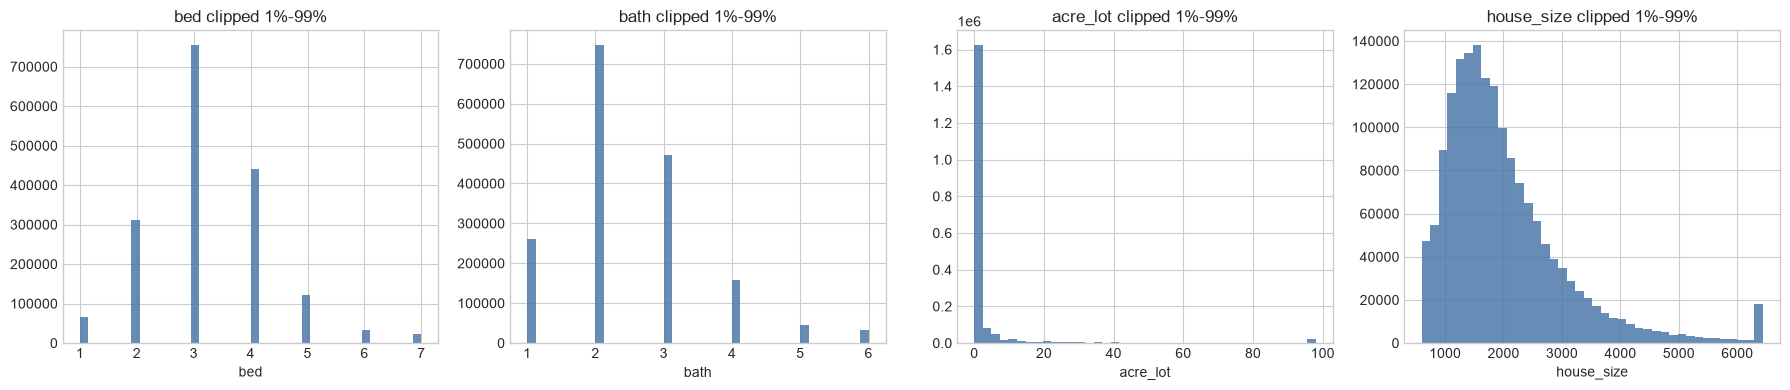

In [25]:
numeric_plot_cols = ["bed", "bath", "acre_lot", "house_size"]
fig, axes = plt.subplots(1, len(numeric_plot_cols), figsize=(18, 4))

for ax, col in zip(axes, numeric_plot_cols):
    values = pd.to_numeric(df_raw[col], errors="coerce")
    values = values[values.notna()]
    values = values.clip(lower=values.quantile(0.01), upper=values.quantile(0.99))
    ax.hist(values, bins=40, color="#4C78A8", alpha=0.85)
    ax.set_title(f"{col} clipped 1%-99%")
    ax.set_xlabel(col)

plt.tight_layout()
save_current_figure("house_price_numeric_feature_distributions.png")
plt.show()


## 5. Cấu hình dữ liệu mô hình

Dataset gốc rất lớn. `SAMPLE_SIZE = 200_000` giúp notebook chạy hợp lý trong môi trường học tập. Đổi `SAMPLE_SIZE = None` nếu muốn huấn luyện trên toàn bộ dataset và máy đủ RAM/thời gian.


In [26]:
SAMPLE_SIZE = 200_000
MIN_PRICE = 1.0

df_model = df_raw.copy()
df_model["price"] = pd.to_numeric(df_model["price"], errors="coerce")
df_model = df_model[df_model["price"].notna() & (df_model["price"] > MIN_PRICE)].copy()

if SAMPLE_SIZE is not None and len(df_model) > SAMPLE_SIZE:
    df_model = df_model.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df_model = df_model.reset_index(drop=True)

print(f"Rows dùng cho mô hình: {len(df_model):,}")
print(f"Giá thấp nhất/cao nhất: {df_model['price'].min():,.0f} / {df_model['price'].max():,.0f}")
display(df_model[["price", "bed", "bath", "acre_lot", "house_size", "status", "city", "state", "zip_code"]].head())


Rows dùng cho mô hình: 200,000
Giá thấp nhất/cao nhất: 2 / 110,000,000


,price,bed,bath,acre_lot,house_size,status,city,state,zip_code
0,349900.0,3.0,2.0,0.05,1331.0,sold,Stanwood,Washington,98292.0
1,419900.0,4.0,4.0,0.55,3600.0,for_sale,Batavia,Illinois,60510.0
2,150000.0,3.0,2.0,0.16,1898.0,sold,Des Moines,Iowa,50311.0
3,130000.0,1.0,1.0,NaN,NaN,for_sale,Oak Park,Illinois,60302.0
4,9900.0,NaN,NaN,0.80,NaN,for_sale,Grayson,Kentucky,41143.0


## 6. Train / Validation / Test Split

Dataset được chia theo tỷ lệ `70% train`, `15% validation`, `15% test`. Vì đây là regression, notebook tạo bin từ `log1p(price)` để stratify và giữ phân phối giá tương đối ổn định ở cả ba tập.


In [27]:
TARGET = "price"
FEATURE_COLUMNS = [
    "status",
    "bed",
    "bath",
    "acre_lot",
    "city",
    "state",
    "zip_code",
    "house_size",
    "prev_sold_date",
    "brokered_by",
]

def make_price_bins(price_values, n_bins=10):
    log_price = np.log1p(np.asarray(price_values, dtype=np.float64))
    try:
        bins = pd.qcut(log_price, q=n_bins, labels=False, duplicates="drop")
        if pd.Series(bins).nunique(dropna=True) < 2:
            return None
        return bins
    except ValueError:
        return None

X_raw = df_model[FEATURE_COLUMNS].copy()
y = df_model[TARGET].to_numpy(dtype=np.float64)

first_stratify = make_price_bins(y)
X_train_val_raw, X_test_raw, y_train_val, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=first_stratify,
)

validation_size_inside_train_val = 0.15 / 0.85
second_stratify = make_price_bins(y_train_val)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_val_raw,
    y_train_val,
    test_size=validation_size_inside_train_val,
    random_state=RANDOM_STATE,
    stratify=second_stratify,
)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "median_price": [np.median(y_train), np.median(y_val), np.median(y_test)],
    "mean_price": [np.mean(y_train), np.mean(y_val), np.mean(y_test)],
    "p95_price": [np.percentile(y_train, 95), np.percentile(y_val, 95), np.percentile(y_test, 95)],
})
display(split_summary)


,split,rows,median_price,mean_price,p95_price
0,train,139999,325000.0,518577.0947,1495000.0
1,validation,30001,325000.0,522168.7136,1499000.0
2,test,30000,325000.0,521795.0909,1490000.0


## 7. Feature Engineering tránh data leakage

Feature engineer chỉ `fit` trên training set. Validation/test chỉ dùng thống kê đã học từ training set.

- Numeric columns được median impute và thêm missing indicators.
- `acre_lot` và `house_size` có thêm `log1p` vì phân phối lệch.
- `status` và `state` được one-hot encode.
- `city`, `zip_code`, `brokered_by` được frequency/count encode để tránh one-hot quá lớn.
- `prev_sold_date` được tách thành year/month/years_since_prev_sold.
- `street` bị loại vì gần giống định danh từng listing, dễ làm mô hình học nhiễu và tăng cardinality rất lớn.


In [28]:
class HousePriceFeatureEngineer:
    def __init__(
        self,
        numeric_cols,
        low_card_categorical_cols,
        frequency_cols,
        date_col="prev_sold_date",
        missing_token="__missing__",
    ):
        self.numeric_cols = numeric_cols
        self.low_card_categorical_cols = low_card_categorical_cols
        self.frequency_cols = frequency_cols
        self.date_col = date_col
        self.missing_token = missing_token

    def fit(self, X):
        X = X.copy()
        self.numeric_medians_ = {}
        for col in self.numeric_cols:
            values = pd.to_numeric(X[col], errors="coerce")
            median = values.median()
            self.numeric_medians_[col] = 0.0 if pd.isna(median) else float(median)

        self.low_card_categories_ = {}
        for col in self.low_card_categorical_cols:
            values = X[col].astype("string").fillna(self.missing_token).astype(str)
            self.low_card_categories_[col] = values.value_counts().index.tolist()

        self.frequency_maps_ = {}
        self.frequency_defaults_ = {}
        train_size = len(X)
        for col in self.frequency_cols:
            values = X[col].astype("string").fillna(self.missing_token).astype(str)
            counts = values.value_counts()
            self.frequency_maps_[col] = counts.to_dict()
            self.frequency_defaults_[col] = 1.0

        dates = pd.to_datetime(X[self.date_col], errors="coerce")
        max_year = dates.dt.year.max()
        self.reference_year_ = int(max_year) if pd.notna(max_year) else 2026

        features = self._build_features(X)
        self.feature_columns_ = features.columns.tolist()
        return self

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def transform(self, X):
        features = self._build_features(X.copy())
        features = features.reindex(columns=self.feature_columns_, fill_value=0.0)
        features = features.replace([np.inf, -np.inf], np.nan).fillna(0.0)
        return features.astype(np.float32)

    def _build_features(self, X):
        features = pd.DataFrame(index=X.index)

        for col in self.numeric_cols:
            values = pd.to_numeric(X[col], errors="coerce")
            missing = values.isna().astype(np.float32)
            filled = values.fillna(self.numeric_medians_[col]).astype(np.float64)
            clipped_nonnegative = np.clip(filled, 0, None)

            features[col] = filled
            features[f"{col}_missing"] = missing
            if col in {"acre_lot", "house_size"}:
                features[f"log1p_{col}"] = np.log1p(clipped_nonnegative)

        for col in self.frequency_cols:
            values = X[col].astype("string").fillna(self.missing_token).astype(str)
            counts = values.map(self.frequency_maps_[col]).astype(float)
            counts = counts.fillna(self.frequency_defaults_[col])
            features[f"{col}_count"] = counts
            features[f"{col}_log_count"] = np.log1p(counts)
            features[f"{col}_frequency"] = counts / max(sum(self.frequency_maps_[col].values()), 1)

        dates = pd.to_datetime(X[self.date_col], errors="coerce")
        year = dates.dt.year.astype("float64")
        month = dates.dt.month.astype("float64")
        missing_date = dates.isna().astype(np.float32)

        features["prev_sold_year"] = year.fillna(self.reference_year_)
        features["prev_sold_month"] = month.fillna(0.0)
        features["years_since_prev_sold"] = (self.reference_year_ - year).clip(lower=0).fillna(0.0)
        features["prev_sold_missing"] = missing_date

        for col in self.low_card_categorical_cols:
            values = X[col].astype("string").fillna(self.missing_token).astype(str)
            known_categories = set(self.low_card_categories_[col])
            for category in self.low_card_categories_[col]:
                features[f"{col}={category}"] = (values == category).astype(np.float32)
            features[f"{col}=__unknown__"] = (~values.isin(known_categories)).astype(np.float32)

        return features


In [29]:
numeric_cols = ["bed", "bath", "acre_lot", "house_size"]
low_card_categorical_cols = ["status", "state"]
frequency_cols = ["city", "zip_code", "brokered_by"]

feature_engineer = HousePriceFeatureEngineer(
    numeric_cols=numeric_cols,
    low_card_categorical_cols=low_card_categorical_cols,
    frequency_cols=frequency_cols,
    date_col="prev_sold_date",
)

X_train_features = feature_engineer.fit_transform(X_train_raw)
X_val_features = feature_engineer.transform(X_val_raw)
X_test_features = feature_engineer.transform(X_test_raw)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_features).astype(np.float32)
X_val = scaler.transform(X_val_features).astype(np.float32)
X_test = scaler.transform(X_test_features).astype(np.float32)

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("Số feature sau engineering:", X_train.shape[1])
display(pd.DataFrame(X_train[:5], columns=feature_engineer.feature_columns_).head())


X_train: (139999, 83)
X_val: (30001, 83)
X_test: (30000, 83)
Số feature sau engineering: 83


,bed,bed_missing,bath,bath_missing,acre_lot,acre_lot_missing,log1p_acre_lot,house_size,house_size_missing,log1p_house_size,city_count,city_log_count,city_frequency,zip_code_count,zip_code_log_count,zip_code_frequency,brokered_by_count,brokered_by_log_count,brokered_by_frequency,prev_sold_year,prev_sold_month,years_since_prev_sold,prev_sold_missing,status=for_sale,status=sold,status=ready_to_build,status=__unknown__,state=Florida,state=California,state=Texas,state=New York,state=Illinois,state=North Carolina,state=Georgia,state=Pennsylvania,state=Arizona,state=Virginia,state=Washington,state=Ohio,state=New Jersey,...,state=South Carolina,state=Michigan,state=Wisconsin,state=Tennessee,state=Massachusetts,state=Oklahoma,state=Alabama,state=Oregon,state=Colorado,state=Kentucky,state=Louisiana,state=Arkansas,state=New Mexico,state=Iowa,state=Indiana,state=Idaho,state=Mississippi,state=Utah,state=Kansas,state=Nevada,state=Connecticut,state=West Virginia,state=Montana,state=Rhode Island,state=Delaware,state=Hawaii,state=District of Columbia,state=Nebraska,state=South Dakota,state=North Dakota,state=Maine,state=Wyoming,state=New Hampshire,state=Puerto Rico,state=Alaska,state=Vermont,state=Virgin Islands,state=Guam,state=__missing__,state=__unknown__
0,1.2861,-0.5256,0.2444,-0.5461,-0.0200,-0.4132,-0.5147,0.1985,-0.5858,1.2944,-0.4627,-0.4793,-0.4627,0.1245,0.5084,0.1245,-0.2476,-0.1468,-0.2476,0.3441,-0.4708,-0.3441,-0.7054,-1.2915,1.3227,-0.106,0.0,-0.3536,2.9700,-0.3218,-0.2233,-0.2008,-0.1997,-0.1927,-0.1903,-0.1824,-0.1787,-0.1694,-0.1653,-0.1489,...,-0.1406,-0.1403,-0.1377,-0.1372,-0.1325,-0.1292,-0.1244,-0.1213,-0.1207,-0.1096,-0.1087,-0.1026,-0.0998,-0.0987,-0.0945,-0.0873,-0.086,-0.0823,-0.082,-0.0815,-0.0787,-0.0754,-0.0666,-0.0625,-0.0623,-0.0562,-0.0547,-0.0515,-0.0476,-0.0465,-0.0463,-0.0412,-0.0405,-0.0388,-0.035,-0.0326,-0.0181,-0.0163,-0.0038,0.0
1,-1.6011,-0.5256,-0.1560,-0.5461,-0.0199,2.4201,-0.3830,-0.1752,-0.5858,-1.2336,3.0215,1.9557,3.0215,-0.3622,-0.0637,-0.3622,1.0029,2.2532,1.0029,0.6137,-0.9485,-0.6137,1.4176,0.7743,-0.7560,-0.106,0.0,-0.3536,-0.3367,-0.3218,4.4776,-0.2008,-0.1997,-0.1927,-0.1903,-0.1824,-0.1787,-0.1694,-0.1653,-0.1489,...,-0.1406,-0.1403,-0.1377,-0.1372,-0.1325,-0.1292,-0.1244,-0.1213,-0.1207,-0.1096,-0.1087,-0.1026,-0.0998,-0.0987,-0.0945,-0.0873,-0.086,-0.0823,-0.082,-0.0815,-0.0787,-0.0754,-0.0666,-0.0625,-0.0623,-0.0562,-0.0547,-0.0515,-0.0476,-0.0465,-0.0463,-0.0412,-0.0405,-0.0388,-0.035,-0.0326,-0.0181,-0.0163,-0.0038,0.0
2,-0.1575,-0.5256,-0.1560,-0.5461,-0.0198,-0.4132,-0.3654,-0.0116,-0.5858,0.2044,-0.0413,0.6665,-0.0413,-0.2405,0.1070,-0.2405,-0.2541,-0.3564,-0.2541,0.2093,1.6790,-0.2093,-0.7054,-1.2915,1.3227,-0.106,0.0,-0.3536,-0.3367,3.1073,-0.2233,-0.2008,-0.1997,-0.1927,-0.1903,-0.1824,-0.1787,-0.1694,-0.1653,-0.1489,...,-0.1406,-0.1403,-0.1377,-0.1372,-0.1325,-0.1292,-0.1244,-0.1213,-0.1207,-0.1096,-0.1087,-0.1026,-0.0998,-0.0987,-0.0945,-0.0873,-0.086,-0.0823,-0.082,-0.0815,-0.0787,-0.0754,-0.0666,-0.0625,-0.0623,-0.0562,-0.0547,-0.0515,-0.0476,-0.0465,-0.0463,-0.0412,-0.0405,-0.0388,-0.035,-0.0326,-0.0181,-0.0163,-0.0038,0.0
3,-0.1575,1.9027,-0.1560,1.8311,-0.0138,-0.4132,1.3303,-0.0459,1.7072,-0.0331,-0.4583,-0.4484,-0.4583,0.1245,0.5084,0.1245,-0.2584,-0.5542,-0.2584,0.3441,0.4847,-0.3441,-0.7054,0.7743,-0.7560,-0.106,0.0,-0.3536,-0.3367,-0.3218,-0.2233,-0.2008,-0.1997,-0.1927,-0.1903,-0.1824,-0.1787,-0.1694,-0.1653,-0.1489,...,-0.1406,-0.1403,-0.1377,-0.1372,-0.1325,-0.1292,-0.1244,-0.1213,-0.1207,-0.1096,-0.1087,-0.1026,10.0187,-0.0987,-0.0945,-0.0873,-0.086,-0.0823,-0.082,-0.0815,-0.0787,-0.0754,-0.0666,-0.0625,-0.0623,-0.0562,-0.0547,-0.0515,-0.0476,-0.0465,-0.0463,-0.0412,-0.0405,-0.0388,-0.035,-0.0326,-0.0181,-0.0163,-0.0038,0.0
4,0.5643,-0.5256,0.2444,-0.5461,-0.0196,-0.4132,-0.2337,0.0668,-0.5858,0.6716,-0.4931,-0.7485,-0.4931,-0.3014,0.0247,-0.3014,-0.2047,0.4991,-0.2047,0.6137,-0.9485,-0.6137,1.4176,0.7743,-0.7560,-0.106,0.0,-0.3536,-0.3367,-0.3218,-0.2233,-0.2

## 8. Hàm đánh giá benchmark regression

Các mô hình dự đoán trên thang `log1p(price)`. Hàm đánh giá chuyển prediction về USD rồi tính metric trên test set.


In [30]:
max_log_prediction = np.log1p(np.percentile(y_train, 99.9) * 5.0)

def log_price_to_price(y_pred_log):
    y_pred_log = np.asarray(y_pred_log, dtype=np.float64)
    y_pred_log = np.clip(y_pred_log, 0.0, max_log_prediction)
    return np.expm1(y_pred_log)


def regression_metrics(y_true_price, y_pred_log):
    y_pred_price = log_price_to_price(y_pred_log)
    errors = y_true_price - y_pred_price
    mae = mean_absolute_error(y_true_price, y_pred_price)
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    medae = median_absolute_error(y_true_price, y_pred_price)
    mape = float(np.mean(np.abs(errors) / np.maximum(y_true_price, 1.0)))
    rmsle = float(np.sqrt(np.mean((np.log1p(y_true_price) - np.log1p(y_pred_price)) ** 2)))
    r2 = r2_score(y_true_price, y_pred_price)
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MedianAE": medae,
        "MAPE": mape,
        "RMSLE": rmsle,
        "R2": r2,
    }


def evaluate_regression_model(name, y_true_price, y_pred_log, train_time, predict_time):
    metrics = regression_metrics(y_true_price, y_pred_log)
    metrics.update({
        "Model": name,
        "Train time (s)": train_time,
        "Predict time (s)": predict_time,
    })
    return metrics


def display_regression_results(results):
    ordered_columns = [
        "Model", "MAE", "RMSE", "MedianAE", "MAPE", "RMSLE", "R2",
        "Train time (s)", "Predict time (s)",
    ]
    results_df = pd.DataFrame(results)[ordered_columns]
    results_df = results_df.sort_values(["RMSLE", "MAE"], ascending=[True, True]).reset_index(drop=True)
    display(results_df.style.format({
        "MAE": "${:,.0f}",
        "RMSE": "${:,.0f}",
        "MedianAE": "${:,.0f}",
        "MAPE": "{:.2%}",
        "RMSLE": "{:.4f}",
        "R2": "{:.4f}",
        "Train time (s)": "{:.3f}",
        "Predict time (s)": "{:.3f}",
    }))
    return results_df


## 9. Huấn luyện 3 mô hình Machine Learning cơ bản

Ba mô hình này dùng cùng một dữ liệu đã feature-engineer và scale để benchmark công bằng với MLP NumPy.


In [31]:
baseline_models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=18,
        min_samples_leaf=50,
        random_state=RANDOM_STATE,
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=60,
        max_depth=16,
        min_samples_leaf=30,
        max_features="sqrt",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

benchmark_results = []
test_predictions = {}
validation_predictions = {}

for model_name, model in baseline_models.items():
    print(f"Training {model_name}...")

    start = time.perf_counter()
    model.fit(X_train, y_train_log)
    train_time = time.perf_counter() - start

    val_pred_log = model.predict(X_val)

    start = time.perf_counter()
    test_pred_log = model.predict(X_test)
    predict_time = time.perf_counter() - start

    result = evaluate_regression_model(
        model_name,
        y_test,
        test_pred_log,
        train_time,
        predict_time,
    )
    benchmark_results.append(result)
    validation_predictions[model_name] = val_pred_log
    test_predictions[model_name] = {
        "log_prediction": test_pred_log,
        "price_prediction": log_price_to_price(test_pred_log),
    }

    val_metrics = regression_metrics(y_val, val_pred_log)
    print(f"  Validation RMSLE: {val_metrics['RMSLE']:.4f}, MAE: ${val_metrics['MAE']:,.0f}")
    print(f"  Test RMSLE: {result['RMSLE']:.4f}, MAE: ${result['MAE']:,.0f}")

baseline_results_df = display_regression_results(benchmark_results)


Training Ridge Regression...
  Validation RMSLE: 0.7694, MAE: $264,134
  Test RMSLE: 0.7717, MAE: $268,912
Training Decision Tree Regressor...
  Validation RMSLE: 0.7156, MAE: $238,756
  Test RMSLE: 0.7205, MAE: $241,108
Training Random Forest Regressor...
  Validation RMSLE: 0.7183, MAE: $245,358
  Test RMSLE: 0.7216, MAE: $247,668


,Model,MAE,RMSE,MedianAE,MAPE,RMSLE,R2,Train time (s),Predict time (s)
0,Decision Tree Regressor,"$241,108","$1,169,286","$87,561",4952.28%,0.7205,0.2408,0.979,0.002
1,Random Forest Regressor,"$247,668","$1,241,475","$87,537",2614.12%,0.7216,0.1442,0.876,0.026
2,Ridge Regression,"$268,912","$1,228,158","$92,871",2871.93%,0.7717,0.1624,0.371,0.001


## 10. MLP đa tầng thuần NumPy

MLP dưới đây không dùng TensorFlow, PyTorch, Keras hay `sklearn.neural_network`. Mạng có kiến trúc `input -> 128 -> 64 -> 32 -> 1`, dùng ReLU ở hidden layers và linear output layer.

Các cải tiến chính:

- Mini-batch training
- Adam optimizer viết bằng NumPy
- L2 regularization
- Target normalization trên `log1p(price)`
- Validation tracking
- Early stopping theo validation RMSLE


In [32]:
class NumpyMLPRegressor:
    def __init__(
        self,
        hidden_layers=(128, 64, 32),
        learning_rate=0.001,
        epochs=60,
        batch_size=2048,
        l2=1e-4,
        patience=8,
        min_delta=1e-4,
        beta1=0.9,
        beta2=0.999,
        epsilon=1e-8,
        random_state=42,
        verbose=True,
    ):
        self.hidden_layers = hidden_layers
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.l2 = l2
        self.patience = patience
        self.min_delta = min_delta
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.random_state = random_state
        self.verbose = verbose

    def _initialize_parameters(self, input_dim):
        rng = np.random.default_rng(self.random_state)
        layer_sizes = [input_dim, *self.hidden_layers, 1]
        self.weights = []
        self.biases = []

        for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
            if fan_out == 1:
                limit = np.sqrt(6.0 / (fan_in + fan_out))
                weight = rng.uniform(-limit, limit, size=(fan_in, fan_out))
            else:
                weight = rng.normal(0.0, np.sqrt(2.0 / fan_in), size=(fan_in, fan_out))
            bias = np.zeros((1, fan_out))

            self.weights.append(weight.astype(np.float64))
            self.biases.append(bias.astype(np.float64))

        self.m_w = [np.zeros_like(weight) for weight in self.weights]
        self.v_w = [np.zeros_like(weight) for weight in self.weights]
        self.m_b = [np.zeros_like(bias) for bias in self.biases]
        self.v_b = [np.zeros_like(bias) for bias in self.biases]
        self.optimizer_step_ = 0

    @staticmethod
    def _relu(x):
        return np.maximum(0.0, x)

    def _forward(self, X):
        current = X.astype(np.float64, copy=False)
        activations = [current]
        z_values = []

        for weight, bias in zip(self.weights[:-1], self.biases[:-1]):
            z = current @ weight + bias
            current = self._relu(z)
            z_values.append(z)
            activations.append(current)

        output = current @ self.weights[-1] + self.biases[-1]
        z_values.append(output)
        activations.append(output)
        return output, {"activations": activations, "z_values": z_values}

    def _loss(self, y_true_scaled, y_pred_scaled):
        residual = y_pred_scaled - y_true_scaled.reshape(-1, 1)
        mse = 0.5 * np.mean(residual ** 2)
        regularization = 0.5 * self.l2 * sum(np.sum(weight ** 2) for weight in self.weights)
        return float(mse + regularization)

    def _backward(self, y_batch_scaled, cache):
        y_batch_scaled = y_batch_scaled.reshape(-1, 1)
        batch_size = len(y_batch_scaled)
        activations = cache["activations"]
        z_values = cache["z_values"]

        d_z = (activations[-1] - y_batch_scaled) / batch_size
        grad_weights = [None] * len(self.weights)
        grad_biases = [None] * len(self.biases)

        for layer_idx in reversed(range(len(self.weights))):
            previous_activation = activations[layer_idx]
            grad_weights[layer_idx] = previous_activation.T @ d_z + self.l2 * self.weights[layer_idx]
            grad_biases[layer_idx] = np.sum(d_z, axis=0, keepdims=True)

            if layer_idx > 0:
                d_activation = d_z @ self.weights[layer_idx].T
                d_z = d_activation * (z_values[layer_idx - 1] > 0)

        return grad_weights, grad_biases

    def _adam_update(self, grad_weights, grad_biases):
        self.optimizer_step_ += 1
        t = self.optimizer_step_

        for idx in range(len(self.weights)):
            self.m_w[idx] = self.beta1 * self.m_w[idx] + (1.0 - self.beta1) * grad_weights[idx]
            self.v_w[idx] = self.beta2 * self.v_w[idx] + (1.0 - self.beta2) * (grad_weights[idx] ** 2)
            self.m_b[idx] = self.beta1 * self.m_b[idx] + (1.0 - self.beta1) * grad_biases[idx]
            self.v_b[idx] = self.beta2 * self.v_b[idx] + (1.0 - self.beta2) * (grad_biases[idx] ** 2)

            m_w_hat = self.m_w[idx] / (1.0 - self.beta1 ** t)
            v_w_hat = self.v_w[idx] / (1.0 - self.beta2 ** t)
            m_b_hat = self.m_b[idx] / (1.0 - self.beta1 ** t)
            v_b_hat = self.v_b[idx] / (1.0 - self.beta2 ** t)

            self.weights[idx] -= self.learning_rate * m_w_hat / (np.sqrt(v_w_hat) + self.epsilon)
            self.biases[idx] -= self.learning_rate * m_b_hat / (np.sqrt(v_b_hat) + self.epsilon)

    def _copy_parameters(self):
        return {
            "weights": [weight.copy() for weight in self.weights],
            "biases": [bias.copy() for bias in self.biases],
        }

    def _restore_parameters(self, parameters):
        self.weights = [weight.copy() for weight in parameters["weights"]]
        self.biases = [bias.copy() for bias in parameters["biases"]]

    def _scale_target(self, y_log):
        return (y_log - self.y_mean_) / self.y_std_

    def _unscale_target(self, y_scaled):
        return y_scaled * self.y_std_ + self.y_mean_

    def fit(self, X_train, y_train_log, X_val, y_val_log):
        self.y_mean_ = float(np.mean(y_train_log))
        self.y_std_ = float(np.std(y_train_log))
        if self.y_std_ == 0:
            self.y_std_ = 1.0

        y_train_scaled = self._scale_target(y_train_log)
        y_val_log = np.asarray(y_val_log, dtype=np.float64)

        self._initialize_parameters(input_dim=X_train.shape[1])
        rng = np.random.default_rng(self.random_state)

        self.history_ = []
        best_score = np.inf
        best_epoch = 0
        best_parameters = self._copy_parameters()
        epochs_without_improvement = 0

        for epoch in range(1, self.epochs + 1):
            shuffled_indices = rng.permutation(len(X_train))
            batch_losses = []

            for start in range(0, len(X_train), self.batch_size):
                batch_indices = shuffled_indices[start:start + self.batch_size]
                X_batch = X_train[batch_indices]
                y_batch_scaled = y_train_scaled[batch_indices]

                y_pred_scaled, cache = self._forward(X_batch)
                batch_losses.append(self._loss(y_batch_scaled, y_pred_scaled))

                grad_weights, grad_biases = self._backward(y_batch_scaled, cache)
                self._adam_update(grad_weights, grad_biases)

            train_loss = float(np.mean(batch_losses))
            val_pred_log = self.predict(X_val)
            val_pred_price = log_price_to_price(val_pred_log)
            val_true_price = np.expm1(y_val_log)
            val_rmsle = float(np.sqrt(np.mean((y_val_log - np.log1p(val_pred_price)) ** 2)))
            val_mae = mean_absolute_error(val_true_price, val_pred_price)

            record = {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_rmsle": val_rmsle,
                "val_mae": val_mae,
            }
            self.history_.append(record)

            if self.verbose and (epoch == 1 or epoch % 5 == 0):
                print(
                    f"Epoch {epoch:03d} | "
                    f"train_loss={train_loss:.4f} | "
                    f"val_rmsle={val_rmsle:.4f} | "
                    f"val_mae=${val_mae:,.0f}"
                )

            if val_rmsle < best_score - self.min_delta:
                best_score = val_rmsle
                best_epoch = epoch
                best_parameters = self._copy_parameters()
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= self.patience:
                if self.verbose:
                    print(f"Early stopping tại epoch {epoch}. Best epoch: {best_epoch}")
                break

        self._restore_parameters(best_parameters)
        self.best_epoch_ = best_epoch
        self.best_validation_rmsle_ = best_score
        return self

    def predict(self, X):
        y_scaled, _ = self._forward(X)
        return self._unscale_target(y_scaled.ravel())


## 11. Huấn luyện MLP NumPy

Cell này có thể chạy lâu hơn các mô hình ML cơ bản vì toàn bộ forward/backpropagation và Adam optimizer được viết bằng NumPy thuần.


In [33]:
mlp = NumpyMLPRegressor(
    hidden_layers=(128, 64, 32),
    learning_rate=0.001,
    epochs=60,
    batch_size=2048,
    l2=1e-4,
    patience=8,
    min_delta=1e-4,
    random_state=RANDOM_STATE,
    verbose=True,
)

start = time.perf_counter()
mlp.fit(X_train, y_train_log, X_val, y_val_log)
mlp_train_time = time.perf_counter() - start

mlp_val_pred_log = mlp.predict(X_val)

start = time.perf_counter()
mlp_test_pred_log = mlp.predict(X_test)
mlp_predict_time = time.perf_counter() - start

mlp_result = evaluate_regression_model(
    "NumPy MLP (128-64-32)",
    y_test,
    mlp_test_pred_log,
    mlp_train_time,
    mlp_predict_time,
)

benchmark_results.append(mlp_result)
validation_predictions["NumPy MLP (128-64-32)"] = mlp_val_pred_log
test_predictions["NumPy MLP (128-64-32)"] = {
    "log_prediction": mlp_test_pred_log,
    "price_prediction": log_price_to_price(mlp_test_pred_log),
}

print(f"Best epoch: {mlp.best_epoch_}")
print(f"Best validation RMSLE: {mlp.best_validation_rmsle_:.4f}")
print(f"Test RMSLE: {mlp_result['RMSLE']:.4f}, MAE: ${mlp_result['MAE']:,.0f}")


Epoch 001 | train_loss=0.3425 | val_rmsle=0.7666 | val_mae=$268,726
Epoch 005 | train_loss=0.1998 | val_rmsle=0.6864 | val_mae=$235,936
Epoch 010 | train_loss=0.1892 | val_rmsle=0.6783 | val_mae=$233,038
Epoch 015 | train_loss=0.1786 | val_rmsle=0.6651 | val_mae=$225,513
Epoch 020 | train_loss=0.1735 | val_rmsle=0.6624 | val_mae=$225,419
Epoch 025 | train_loss=0.1719 | val_rmsle=0.6639 | val_mae=$226,255
Epoch 030 | train_loss=0.1711 | val_rmsle=0.6604 | val_mae=$224,019
Epoch 035 | train_loss=0.1660 | val_rmsle=0.6595 | val_mae=$220,152
Epoch 040 | train_loss=0.1648 | val_rmsle=0.6595 | val_mae=$221,415
Epoch 045 | train_loss=0.1634 | val_rmsle=0.6587 | val_mae=$218,413
Epoch 050 | train_loss=0.1615 | val_rmsle=0.6580 | val_mae=$221,877
Epoch 055 | train_loss=0.1604 | val_rmsle=0.6579 | val_mae=$218,556
Epoch 060 | train_loss=0.1621 | val_rmsle=0.6629 | val_mae=$231,845
Early stopping tại epoch 60. Best epoch: 52
Best epoch: 52
Best validation RMSLE: 0.6561
Test RMSLE: 0.6578, MAE: $2

## 12. Learning curve của MLP

Biểu đồ giúp kiểm tra MLP học ổn định không và early stopping dừng ở giai đoạn nào.


,epoch,train_loss,val_rmsle,val_mae
55,56,0.1626,0.6584,219374.0294
56,57,0.1616,0.6564,218001.5586
57,58,0.1631,0.6576,219347.8570
58,59,0.1638,0.6641,218772.5622
59,60,0.1621,0.6629,231845.3054


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/house_price/report/figures/house_price_mlp_learning_curve.png


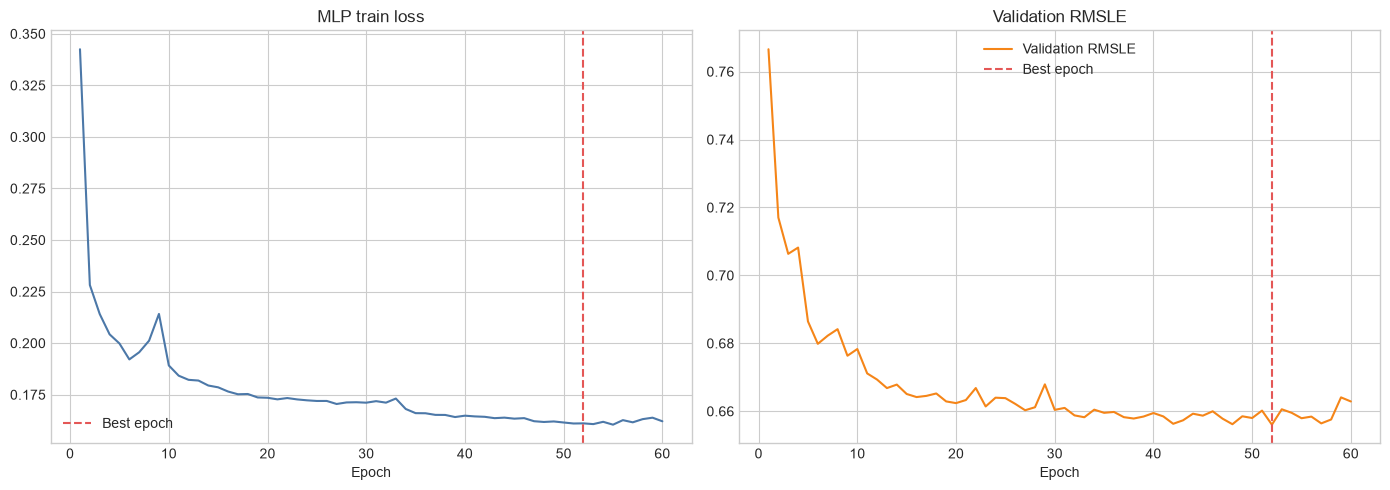

In [34]:
history_df = pd.DataFrame(mlp.history_)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], color="#4C78A8")
axes[0].axvline(mlp.best_epoch_, color="#E45756", linestyle="--", label="Best epoch")
axes[0].set_title("MLP train loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_rmsle"], label="Validation RMSLE", color="#F58518")
axes[1].axvline(mlp.best_epoch_, color="#E45756", linestyle="--", label="Best epoch")
axes[1].set_title("Validation RMSLE")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
save_current_figure("house_price_mlp_learning_curve.png")
plt.show()


## 13. Benchmark toàn diện 4 mô hình

Bảng dưới đây là kết quả trên test set. Với regression giá nhà, `RMSLE` và `MAE` thường hữu ích hơn nhìn riêng `R2`, vì target `price` có nhiều outlier và phân phối lệch mạnh.


In [35]:
results_df = display_regression_results(benchmark_results)
results_df


,Model,MAE,RMSE,MedianAE,MAPE,RMSLE,R2,Train time (s),Predict time (s)
0,NumPy MLP (128-64-32),"$217,538","$1,094,044","$77,432",3460.65%,0.6578,0.3354,16.788,0.026
1,Decision Tree Regressor,"$241,108","$1,169,286","$87,561",4952.28%,0.7205,0.2408,0.979,0.002
2,Random Forest Regressor,"$247,668","$1,241,475","$87,537",2614.12%,0.7216,0.1442,0.876,0.026
3,Ridge Regression,"$268,912","$1,228,158","$92,871",2871.93%,0.7717,0.1624,0.371,0.001


,Model,MAE,RMSE,MedianAE,MAPE,RMSLE,R2,Train time (s),Predict time (s)
0,NumPy MLP (128-64-32),217538.2928,1.0940e+06,77431.5549,34.6065,0.6578,0.3354,16.7879,0.0264
1,Decision Tree Regressor,241108.3792,1.1693e+06,87561.4834,49.5228,0.7205,0.2408,0.9791,0.0020
2,Random Forest Regressor,247668.3130,1.2415e+06,87536.9973,26.1412,0.7216,0.1442,0.8762,0.0264
3,Ridge Regression,268911.8762,1.2282e+06,92871.0451,28.7193,0.7717,0.1624,0.3712,0.0005


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/house_price/report/figures/house_price_metric_comparison.png


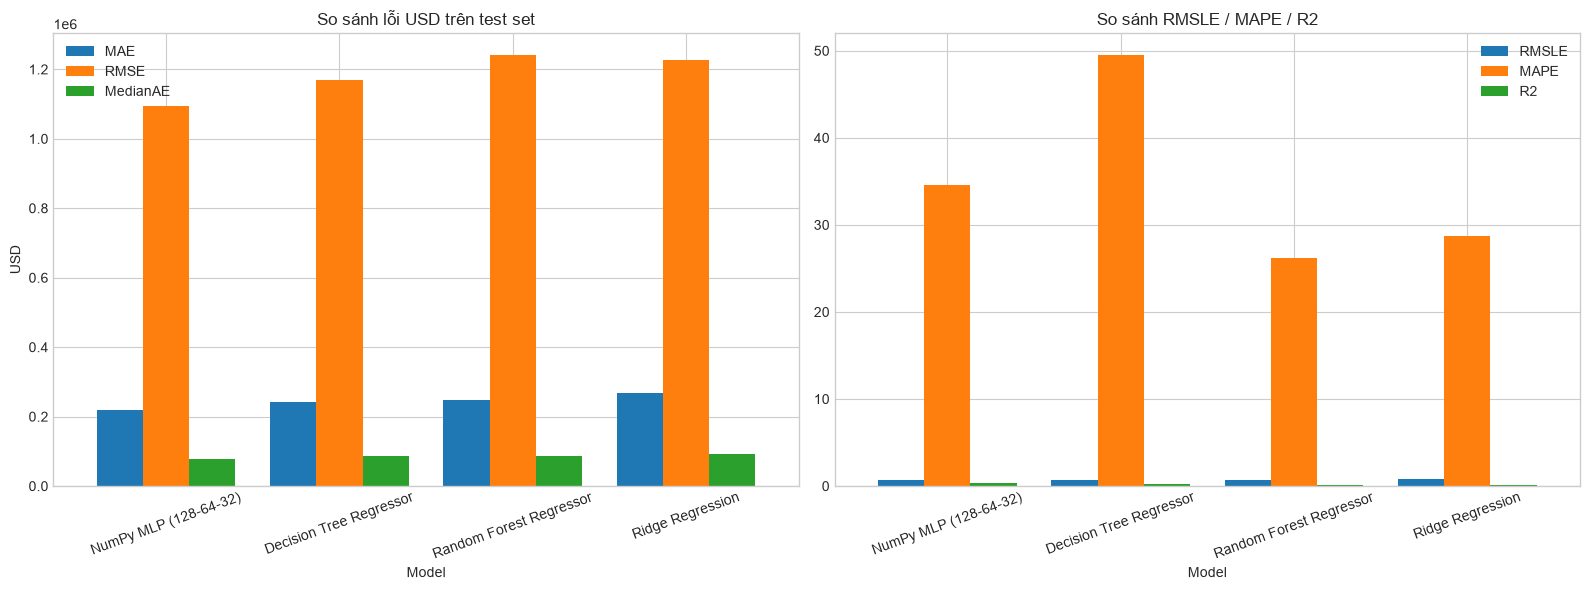

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

error_plot = results_df.set_index("Model")[["MAE", "RMSE", "MedianAE"]]
error_plot.plot(kind="bar", ax=axes[0], width=0.8)
axes[0].set_title("So sánh lỗi USD trên test set")
axes[0].set_ylabel("USD")
axes[0].tick_params(axis="x", rotation=20)

score_plot = results_df.set_index("Model")[["RMSLE", "MAPE", "R2"]]
score_plot.plot(kind="bar", ax=axes[1], width=0.8)
axes[1].set_title("So sánh RMSLE / MAPE / R2")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
save_current_figure("house_price_metric_comparison.png")
plt.show()


## 14. Residual analysis

Biểu đồ predicted-vs-actual và residual giúp nhìn xem mô hình sai nhiều ở nhóm giá thấp hay giá cao.


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/house_price/report/figures/house_price_residual_analysis.png


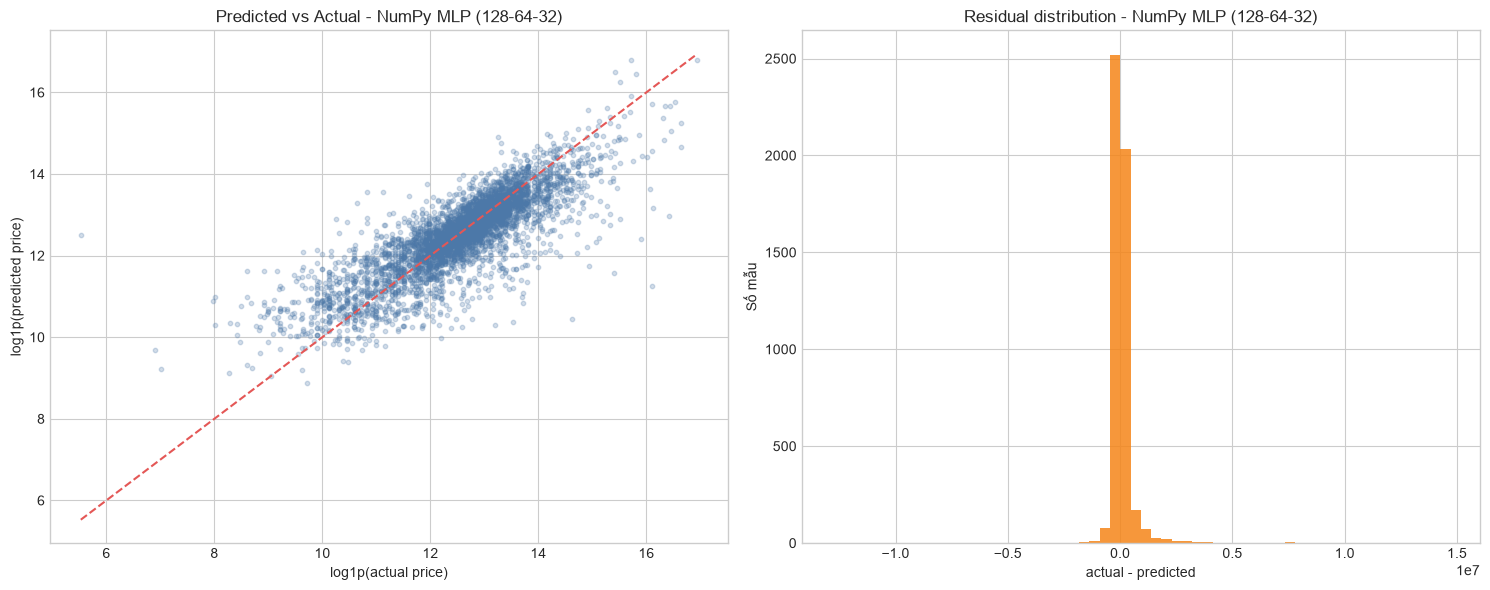

In [37]:
best_model_name = results_df.iloc[0]["Model"]
best_pred_price = test_predictions[best_model_name]["price_prediction"]

sample_size_for_plot = min(5000, len(y_test))
rng = np.random.default_rng(RANDOM_STATE)
plot_indices = rng.choice(len(y_test), size=sample_size_for_plot, replace=False)

actual_sample = y_test[plot_indices]
predicted_sample = best_pred_price[plot_indices]
residual_sample = actual_sample - predicted_sample

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(np.log1p(actual_sample), np.log1p(predicted_sample), alpha=0.25, s=10, color="#4C78A8")
min_axis = min(np.log1p(actual_sample).min(), np.log1p(predicted_sample).min())
max_axis = max(np.log1p(actual_sample).max(), np.log1p(predicted_sample).max())
axes[0].plot([min_axis, max_axis], [min_axis, max_axis], color="#E45756", linestyle="--")
axes[0].set_title(f"Predicted vs Actual - {best_model_name}")
axes[0].set_xlabel("log1p(actual price)")
axes[0].set_ylabel("log1p(predicted price)")

axes[1].hist(residual_sample, bins=60, color="#F58518", alpha=0.85)
axes[1].set_title(f"Residual distribution - {best_model_name}")
axes[1].set_xlabel("actual - predicted")
axes[1].set_ylabel("Số mẫu")

plt.tight_layout()
save_current_figure("house_price_residual_analysis.png")
plt.show()


## 15. Feature importance

Với mô hình cây, feature importance giúp kiểm tra model đang dựa nhiều vào thông tin nào. Phần này dùng Random Forest nếu mô hình đã được huấn luyện thành công.


,feature,importance
2,bath,0.1223
9,log1p_house_size,0.1156
3,bath_missing,0.1144
7,house_size,0.0907
1,bed_missing,0.0859
8,house_size_missing,0.0740
4,acre_lot,0.0673
6,log1p_acre_lot,0.0617
28,state=California,0.0481
0,bed,0.0421


Saved figure: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assigment 03/house_price/report/figures/house_price_random_forest_feature_importance.png


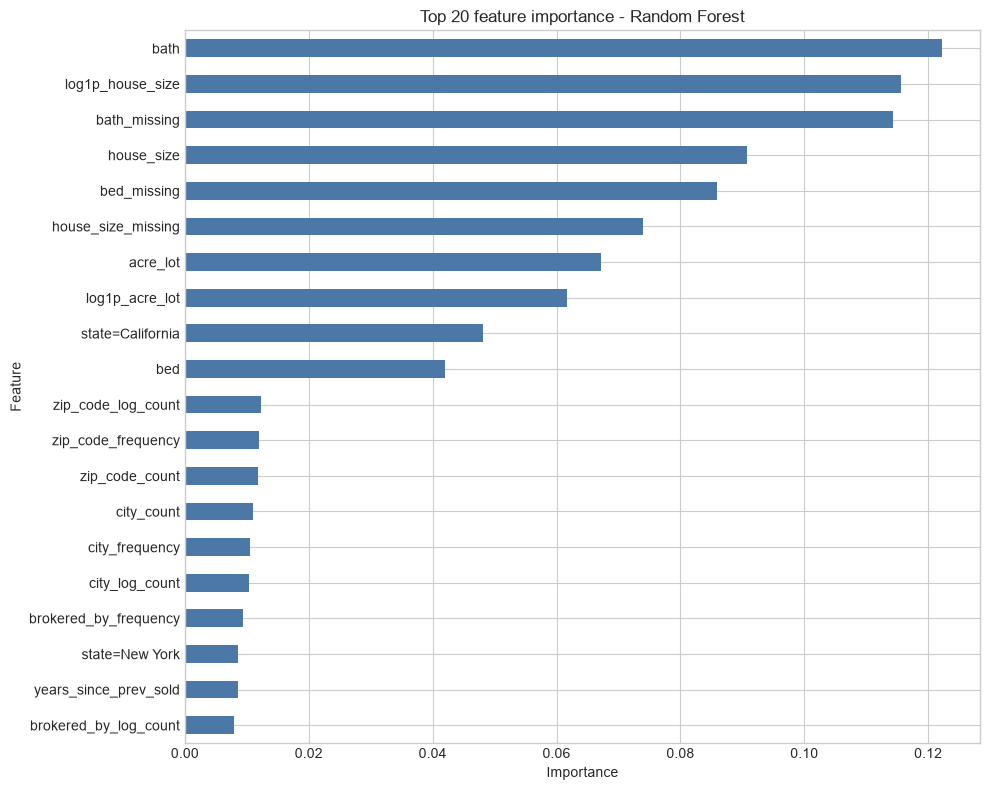

In [38]:
rf_model = baseline_models.get("Random Forest Regressor")
if hasattr(rf_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_engineer.feature_columns_,
        "importance": rf_model.feature_importances_,
    }).sort_values("importance", ascending=False).head(20)

    display(importance_df)

    ax = importance_df.sort_values("importance").plot(
        kind="barh",
        x="feature",
        y="importance",
        figsize=(10, 8),
        legend=False,
        color="#4C78A8",
    )
    ax.set_title("Top 20 feature importance - Random Forest")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    save_current_figure("house_price_random_forest_feature_importance.png")
    plt.show()
else:
    print("Random Forest chưa có feature_importances_.")


## 16. Kết luận

Với house price regression, không nên chọn mô hình chỉ theo một metric. `RMSLE` phản ánh sai số tỷ lệ trên thang log, còn `MAE` dễ hiểu theo đơn vị USD. Nếu mục tiêu là định giá thực tế, ưu tiên mô hình có RMSLE thấp và MAE/MedianAE hợp lý.


In [39]:
best_by_rmsle = results_df.sort_values("RMSLE", ascending=True).iloc[0]
best_by_mae = results_df.sort_values("MAE", ascending=True).iloc[0]
best_by_r2 = results_df.sort_values("R2", ascending=False).iloc[0]

print("Kết luận benchmark:")
print(f"- Mô hình tốt nhất theo RMSLE: {best_by_rmsle['Model']} ({best_by_rmsle['RMSLE']:.4f})")
print(f"- Mô hình tốt nhất theo MAE: {best_by_mae['Model']} (${best_by_mae['MAE']:,.0f})")
print(f"- Mô hình tốt nhất theo R2: {best_by_r2['Model']} ({best_by_r2['R2']:.4f})")
print("- Với target price lệch mạnh, RMSLE và MAE nên được ưu tiên hơn accuracy-style thinking.")

display(results_df)


Kết luận benchmark:
- Mô hình tốt nhất theo RMSLE: NumPy MLP (128-64-32) (0.6578)
- Mô hình tốt nhất theo MAE: NumPy MLP (128-64-32) ($217,538)
- Mô hình tốt nhất theo R2: NumPy MLP (128-64-32) (0.3354)
- Với target price lệch mạnh, RMSLE và MAE nên được ưu tiên hơn accuracy-style thinking.


,Model,MAE,RMSE,MedianAE,MAPE,RMSLE,R2,Train time (s),Predict time (s)
0,NumPy MLP (128-64-32),217538.2928,1.0940e+06,77431.5549,34.6065,0.6578,0.3354,16.7879,0.0264
1,Decision Tree Regressor,241108.3792,1.1693e+06,87561.4834,49.5228,0.7205,0.2408,0.9791,0.0020
2,Random Forest Regressor,247668.3130,1.2415e+06,87536.9973,26.1412,0.7216,0.1442,0.8762,0.0264
3,Ridge Regression,268911.8762,1.2282e+06,92871.0451,28.7193,0.7717,0.1624,0.3712,0.0005
